In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Proje ana dizinine erişebilmek için Python yoluna ekliyoruz
sys.path.append(os.path.abspath(".."))
from src.data_loader import DataLoader

# Veriyi bir üst klasördeki (..) data/raw dizininden yüklüyoruz
loader = DataLoader(raw_data_dir="../data/raw", processed_data_dir="../data/processed")
train_df, test_df = loader.load_raw_data()

--BİLGİ-- Ham veriler başarıyla yüklenmiştir:
        - Train Seti: (891, 12)
        - Test Seti : (418, 11)


In [2]:
print("--- TRAIN SETI GENEL BILGI ---")
print(train_df.info())

print("\n--- EKSIK DEGER SAYILARI (TRAIN) ---")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

print("\n--- EKSIK DEGER SAYILARI (TEST) ---")
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

--- TRAIN SETI GENEL BILGI ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

--- EKSIK DEGER SAYILARI (TRAIN) ---
Age         177
Cabin       687
Embarked      2
dtype: int64

--- EKSIK DEGER SAYILARI (TEST) ---
Age       86
Fare       1
Cabin    327
dtype: int64


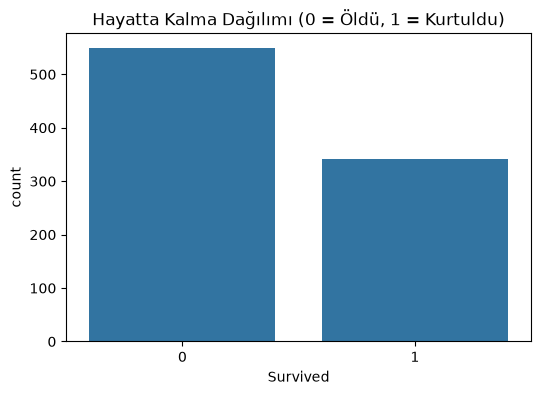

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='Survived')
plt.title('Hayatta Kalma Dağılımı (0 = Öldü, 1 = Kurtuldu)')
plt.show()

print(train_df['Survived'].value_counts(normalize=True) * 100)

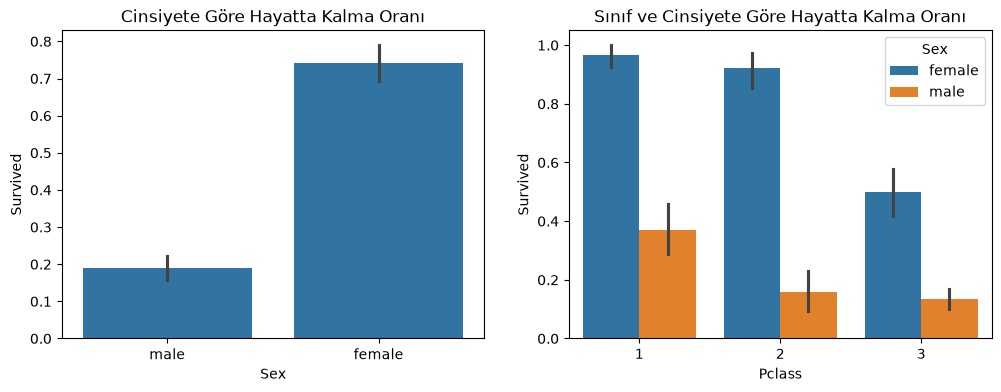

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=train_df, x='Sex', y='Survived', ax=axes[0])
axes[0].set_title('Cinsiyete Göre Hayatta Kalma Oranı')

sns.barplot(data=train_df, x='Pclass', y='Survived', hue='Sex', ax=axes[1])
axes[1].set_title('Sınıf ve Cinsiyete Göre Hayatta Kalma Oranı')

plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, ax=axes[0])
axes[0].set_title('Yaş Dağılımı ve Hayatta Kalma')

sns.boxplot(data=train_df, x='Survived', y='Fare', ax=axes[1])
axes[1].set_title('Bilet Ücreti Dağılımı')

plt.show()